In [28]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ============================================================
# Paths
# ============================================================

# TCD
TOP_ROOT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/"
    + "experiments/v2.0/rf_grid"
)

# Conventional Conv1d decoder
BOTTOM_ROOT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/"
    + "experiments/v2.0/rf_grid_conv1d"
)

OUTPUT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/"
    + "experiments/v2.0"
)

OUTPUT_PDF = OUTPUT_DIR / "rf_grid_validation_comparison.pdf"
OUTPUT_PNG = OUTPUT_DIR / "rf_grid_validation_comparison.png"

DIR_PATTERN = re.compile(
    r"v2\.0_vctk_conv-RF=(\d+)\+text-RF=(\d+)"
)


# ============================================================
# Plot style
# ============================================================

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 10


In [29]:
def load_best_validation_results(
    root_dir: Path,
    *,
    dir_pattern: re.Pattern[str] = DIR_PATTERN,
) -> pd.DataFrame:
    """
    각 RF configuration의 eval_metrics.csv를 읽고,
    validation WBE가 가장 낮은 checkpoint를 선택합니다.

    P25는 해당 WBE-minimum checkpoint에서 가져옵니다.
    """
    if not root_dir.exists():
        raise FileNotFoundError(
            f"Experiment root does not exist: {root_dir}"
        )

    records: list[dict[str, int | float | str]] = []

    required_columns = {
        "step",
        "word_boundary_error",
        "p_word_25ms",
    }

    for exp_dir in sorted(root_dir.iterdir()):
        if not exp_dir.is_dir():
            continue

        match = dir_pattern.fullmatch(exp_dir.name)
        if match is None:
            continue

        conv_rf = int(match.group(1))
        text_rf = int(match.group(2))

        csv_path = exp_dir / "eval_metrics.csv"

        if not csv_path.exists():
            print(f"[SKIP] Missing: {csv_path}")
            continue

        df = pd.read_csv(csv_path)

        missing_columns = required_columns - set(df.columns)

        if missing_columns:
            print(
                f"[SKIP] Missing columns in {csv_path}: "
                f"{sorted(missing_columns)}"
            )
            continue

        df = (
            df[
                [
                    "step",
                    "word_boundary_error",
                    "p_word_25ms",
                ]
            ]
            .dropna(
                subset=[
                    "step",
                    "word_boundary_error",
                    "p_word_25ms",
                ]
            )
            .copy()
        )

        if df.empty:
            print(f"[SKIP] No valid rows: {csv_path}")
            continue

        # Validation WBE가 가장 낮은 checkpoint
        best_idx = df["word_boundary_error"].idxmin()
        best_row = df.loc[best_idx]

        if conv_rf > 13:
            continue

        if text_rf > 7:
            continue

        record = {
            "experiment": exp_dir.name,
            "conv_rf": conv_rf,
            "text_rf": text_rf,
            "best_step": int(best_row["step"]),
            "wbe_ms": (
                float(best_row["word_boundary_error"])
                * 1000.0
            ),
            # WBE minimum과 동일한 checkpoint의 P25
            "p25": float(best_row["p_word_25ms"]),
        }

        records.append(record)

        print(
            f"[LOAD] {root_dir.name:20s} | "
            f"conv-RF={conv_rf:2d}, "
            f"text-RF={text_rf:2d} | "
            f"step={record['best_step']:6d} | "
            f"WBE={record['wbe_ms']:.3f} ms | "
            f"P25={record['p25']:.3f}%"
        )

    if not records:
        raise RuntimeError(
            f"No valid validation results found in {root_dir}"
        )

    result_df = pd.DataFrame(records)

    # 같은 RF 조합이 중복되었는지 검사
    duplicate_mask = result_df.duplicated(
        subset=["conv_rf", "text_rf"],
        keep=False,
    )

    if duplicate_mask.any():
        duplicates = result_df.loc[
            duplicate_mask,
            ["experiment", "conv_rf", "text_rf"],
        ]

        raise ValueError(
            "Duplicate RF configurations found:\n"
            + f"{duplicates.to_string(index=False)}"
        )

    return (
        result_df
        .sort_values(
            ["text_rf", "conv_rf"]
        )
        .reset_index(drop=True)
    )

In [30]:
top_df = load_best_validation_results(
    TOP_ROOT_DIR
)

print("\n" + "=" * 100 + "\n")

bottom_df = load_best_validation_results(
    BOTTOM_ROOT_DIR
)


print("\nTop-row results")
display(top_df)

print("\nBottom-row results")
display(bottom_df)

[LOAD] rf_grid              | conv-RF= 1, text-RF= 1 | step=162500 | WBE=23.709 ms | P25=70.331%
[LOAD] rf_grid              | conv-RF= 1, text-RF= 3 | step=133000 | WBE=23.414 ms | P25=67.694%
[LOAD] rf_grid              | conv-RF= 1, text-RF= 5 | step=173000 | WBE=23.106 ms | P25=68.581%
[LOAD] rf_grid              | conv-RF= 1, text-RF= 7 | step= 60500 | WBE=22.641 ms | P25=70.635%
[LOAD] rf_grid              | conv-RF=11, text-RF= 1 | step=116000 | WBE=20.406 ms | P25=73.483%
[LOAD] rf_grid              | conv-RF=11, text-RF= 3 | step=164000 | WBE=20.725 ms | P25=74.556%
[LOAD] rf_grid              | conv-RF=11, text-RF= 5 | step=148000 | WBE=20.323 ms | P25=74.416%
[LOAD] rf_grid              | conv-RF=11, text-RF= 7 | step= 89000 | WBE=20.793 ms | P25=74.090%
[LOAD] rf_grid              | conv-RF=13, text-RF= 1 | step=139500 | WBE=20.467 ms | P25=73.459%
[LOAD] rf_grid              | conv-RF=13, text-RF= 3 | step=141000 | WBE=20.495 ms | P25=73.553%
[LOAD] rf_grid              | 

,experiment,conv_rf,text_rf,best_step,wbe_ms,p25
0,v2.0_vctk_conv-RF=1+text-RF=1,1,1,162500,23.708912,70.331466
1,v2.0_vctk_conv-RF=3+text-RF=1,3,1,148000,23.152087,67.460316
2,v2.0_vctk_conv-RF=5+text-RF=1,5,1,173000,21.887988,71.661997
3,v2.0_vctk_conv-RF=7+text-RF=1,7,1,150500,20.913295,73.716152
4,v2.0_vctk_conv-RF=9+text-RF=1,9,1,155000,20.193584,75.140059
5,v2.0_vctk_conv-RF=11+text-RF=1,11,1,116000,20.406038,73.482728
6,v2.0_vctk_conv-RF=13+text-RF=1,13,1,139500,20.466929,73.459381
7,v2.0_vctk_conv-RF=1+text-RF=3,1,3,133000,23.413580,67.693746
8,v2.0_vctk_conv-RF=3+text-RF=3,3,3,69000,22.874180,69.000936
9,v2.0_vctk_conv-RF=5+text-RF=3,5,3,148000,21.750987,71.895427



Bottom-row results


,experiment,conv_rf,text_rf,best_step,wbe_ms,p25
0,v2.0_vctk_conv-RF=1+text-RF=1,1,1,162500,24.681449,68.627453
1,v2.0_vctk_conv-RF=3+text-RF=1,3,1,41500,23.306452,68.300653
2,v2.0_vctk_conv-RF=5+text-RF=1,5,1,132000,21.809399,70.751631
3,v2.0_vctk_conv-RF=7+text-RF=1,7,1,171000,22.954047,68.464053
4,v2.0_vctk_conv-RF=9+text-RF=1,9,1,163500,23.394791,68.137252
5,v2.0_vctk_conv-RF=11+text-RF=1,11,1,163500,23.535205,66.993463
6,v2.0_vctk_conv-RF=13+text-RF=1,13,1,137500,24.187276,65.149391
7,v2.0_vctk_conv-RF=1+text-RF=3,1,3,148000,23.455473,67.366946
8,v2.0_vctk_conv-RF=3+text-RF=3,3,3,128500,22.356765,69.654530
9,v2.0_vctk_conv-RF=5+text-RF=3,5,3,119500,22.626093,70.494866


In [31]:
# ============================================================
# Shared RF axes
# ============================================================

all_conv_rfs = sorted(
    set(top_df["conv_rf"].tolist())
    | set(bottom_df["conv_rf"].tolist())
)

all_text_rfs = sorted(
    set(top_df["text_rf"].tolist())
    | set(bottom_df["text_rf"].tolist())
)


conv_rf_min = min(all_conv_rfs)
conv_rf_max = max(all_conv_rfs)

text_rf_min = min(all_text_rfs)
text_rf_max = max(all_text_rfs)


# ============================================================
# Shared color ranges
# ============================================================

all_wbe = pd.concat(
    [
        top_df["wbe_ms"],
        bottom_df["wbe_ms"],
    ],
    ignore_index=True,
).to_numpy(dtype=float)

all_p25 = pd.concat(
    [
        top_df["p25"],
        bottom_df["p25"],
    ],
    ignore_index=True,
).to_numpy(dtype=float)


# 자동으로 전체 두 행의 min/max 사용
wbe_vmin = float(np.nanmin(all_wbe))
wbe_vmax = float(np.nanmax(all_wbe))

p25_vmin = float(np.nanmin(all_p25))
p25_vmax = float(np.nanmax(all_p25))


# # 필요하면 직접 범위를 지정할 수도 있음
# wbe_vmin, wbe_vmax = 20.0, 28.0
# p25_vmin, p25_vmax = 60.0, 75.0


print(
    f"WBE shared range: "
    f"{wbe_vmin:.3f} -- {wbe_vmax:.3f} ms"
)

print(
    f"P25 shared range: "
    f"{p25_vmin:.3f} -- {p25_vmax:.3f} %"
)

WBE shared range: 19.907 -- 26.437 ms
P25 shared range: 63.072 -- 75.140 %


In [35]:
# ============================================================
# Discrete metric grids
# ============================================================

# Same semantic direction in both columns:
# darker = better.
# WBE_CMAP = "viridis"      # lower WBE -> darker
# P25_CMAP = "viridis_r"    # higher P25 -> darker

# WBE_CMAP = "turbo"      # lower WBE -> darker
# P25_CMAP = "turbo_r"    # higher P25 -> darker

WBE_CMAP = "coolwarm"      # lower WBE -> darker
P25_CMAP = "coolwarm_r"    # higher P25 -> darker


def make_metric_grid(
    result_df: pd.DataFrame,
    *,
    metric_column: str,
) -> np.ndarray:
    """Place measured RF configurations on a discrete grid."""
    pivot = (
        result_df
        .pivot(
            index="text_rf",
            columns="conv_rf",
            values=metric_column,
        )
        .reindex(
            index=all_text_rfs,
            columns=all_conv_rfs,
        )
    )

    return pivot.to_numpy(dtype=float)


In [41]:
def plot_metric_heatmap(
    ax: plt.Axes,
    result_df: pd.DataFrame,
    *,
    metric_column: str,
    cmap: str,
    vmin: float,
    vmax: float,
    show_xlabel: bool,
    show_ylabel: bool,
):
    """Plot only measured RF configurations, with values in each cell."""
    grid = make_metric_grid(
        result_df,
        metric_column=metric_column,
    )

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad("0.96")
    norm = Normalize(vmin=vmin, vmax=vmax)

    image = ax.imshow(
        grid,
        origin="lower",
        interpolation="nearest",
        aspect="equal",
        cmap=cmap_obj,
        norm=norm,
    )


    # Cell values.
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            value = grid[i, j]

            if np.isnan(value):
                continue

            rgba = cmap_obj(norm(value))
            luminance = (
                0.299 * rgba[0]
                + 0.587 * rgba[1]
                + 0.114 * rgba[2]
            )

            text_color = (
                "black"
                if luminance > 0.56
                else "white"
            )

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=10.0,
                fontweight="normal",
                color=text_color,
            )

    # Discrete cell boundaries: subtle, not table-like.
    ax.set_xticks(
        np.arange(-0.5, len(all_conv_rfs), 1),
        minor=True,
    )
    ax.set_yticks(
        np.arange(-0.5, len(all_text_rfs), 1),
        minor=True,
    )
    ax.grid(
        which="minor",
        linewidth=0.45,
        alpha=0.25,
        color="white",
    )
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    ax.set_xticks(
        np.arange(len(all_conv_rfs))
    )
    ax.set_xticklabels(
        all_conv_rfs
    )
    ax.set_yticks(
        np.arange(len(all_text_rfs))
    )
    ax.set_yticklabels(
        all_text_rfs
    )

    if show_xlabel:
        ax.set_xlabel(
            "Convolution RF",
            fontsize=10,
            labelpad=5,
        )
    else:
        ax.tick_params(
            axis="x",
            labelbottom=False,
        )

    if show_ylabel:
        ax.set_ylabel(
            "Text RF",
            fontsize=10,
            labelpad=5,
        )
    else:
        ax.tick_params(
            axis="y",
            labelleft=False,
        )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9,
        length=0,
        pad=2,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("0.35")

    ax.set_aspect("auto")

    return image


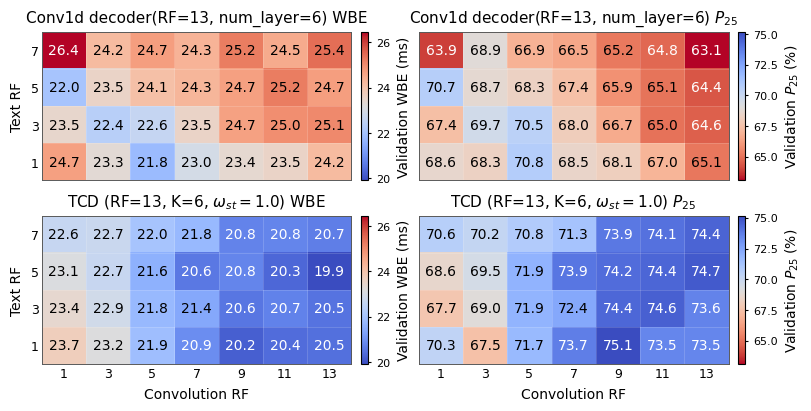

In [42]:
# ============================================================
# Figure layout
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8.0, 4.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)


# ============================================================
# Top row: conventional Conv1d decoder
# ============================================================

im_00 = plot_metric_heatmap(
    axes[0, 0],
    bottom_df,
    metric_column="wbe_ms",
    cmap=WBE_CMAP,
    vmin=wbe_vmin,
    vmax=wbe_vmax,
    show_xlabel=False,
    show_ylabel=True,
)

im_01 = plot_metric_heatmap(
    axes[0, 1],
    bottom_df,
    metric_column="p25",
    cmap=P25_CMAP,
    vmin=p25_vmin,
    vmax=p25_vmax,
    show_xlabel=False,
    show_ylabel=False,
)


# ============================================================
# Bottom row: TCD
# ============================================================

im_10 = plot_metric_heatmap(
    axes[1, 0],
    top_df,
    metric_column="wbe_ms",
    cmap=WBE_CMAP,
    vmin=wbe_vmin,
    vmax=wbe_vmax,
    show_xlabel=True,
    show_ylabel=True,
)

im_11 = plot_metric_heatmap(
    axes[1, 1],
    top_df,
    metric_column="p25",
    cmap=P25_CMAP,
    vmin=p25_vmin,
    vmax=p25_vmax,
    show_xlabel=True,
    show_ylabel=False,
)


# ============================================================
# Titles: same structure as the original figure
# ============================================================

axes[0, 0].set_title(
    "Conv1d decoder(RF=13, num_layer=6) WBE",
    fontsize=11,
    pad=7,
)

axes[0, 1].set_title(
    r"Conv1d decoder(RF=13, num_layer=6) $P_{25}$",
    fontsize=11,
    pad=7,
)

axes[1, 0].set_title(
    r"TCD (RF=13, K=6, $\omega_{st}=1.0$) WBE",
    fontsize=11,
    pad=7,
)

axes[1, 1].set_title(
    r"TCD (RF=13, K=6, $\omega_{st}=1.0$) $P_{25}$",
    fontsize=11,
    pad=7,
)


# ============================================================
# Individual vertical colorbars: same placement as original
# ============================================================

cbar_00 = fig.colorbar(
    im_00,
    ax=axes[0, 0],
    fraction=0.046,
    pad=0.03,
)
cbar_00.set_label(
    "Validation WBE (ms)",
    fontsize=10,
)
cbar_00.ax.tick_params(
    labelsize=8,
    length=2.5,
)

cbar_01 = fig.colorbar(
    im_01,
    ax=axes[0, 1],
    fraction=0.046,
    pad=0.03,
)
cbar_01.set_label(
    r"Validation $P_{25}$ (%)",
    fontsize=10,
)
cbar_01.ax.tick_params(
    labelsize=8,
    length=2.5,
)

cbar_10 = fig.colorbar(
    im_10,
    ax=axes[1, 0],
    fraction=0.046,
    pad=0.03,
)
cbar_10.set_label(
    "Validation WBE (ms)",
    fontsize=10,
)
cbar_10.ax.tick_params(
    labelsize=8,
    length=2.5,
)

cbar_11 = fig.colorbar(
    im_11,
    ax=axes[1, 1],
    fraction=0.046,
    pad=0.03,
)
cbar_11.set_label(
    r"Validation $P_{25}$ (%)",
    fontsize=10,
)
cbar_11.ax.tick_params(
    labelsize=8,
    length=2.5,
)

In [43]:
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved PDF: {OUTPUT_PDF.resolve()}")
print(f"Saved PNG: {OUTPUT_PNG.resolve()}")


Saved PDF: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_validation_comparison.pdf
Saved PNG: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_validation_comparison.png
